In [31]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [32]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 12
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

font_path = os.path.join('..', 'other', 'Roboto', 'Roboto-Regular.ttf')
font_prop = FontProperties(fname = font_path)
fm.fontManager.addfont(font_path)
custom_font_name = font_prop.get_name()

font_path_bold = os.path.join('..', 'other', 'Roboto', 'Roboto-Bold.ttf')
font_prop_bold = FontProperties(fname = font_path_bold)

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = custom_font_name
plt.rcParams['axes.unicode_minus'] = True

In [33]:
results_file = 'ESCAPE35_results.xlsx'

In [34]:
economics_df = pd.read_excel(results_file, sheet_name = 'economics')
economics_df_final = economics_df.drop(columns = ['Total', 'Low', 'High'])
economics_df_final

,Scenario,Natural gas or Biogas,Carbon dioxide,Hydrogen,Ethylene,Utilities,CAPEX
0,Fossil,0.163974,0.000000,0.000000,0.806611,0.102975,0.107400
1,DAC CO2 + wind H2 + fossil C2H2,0.000000,0.156333,0.468809,0.812757,0.203249,0.196781
2,Biogas + fossil C2H2,0.110835,0.000000,0.000000,0.801360,0.272654,0.140810
3,DAC CO2 + wind H2 + green C2H2,0.000000,0.156333,0.468809,1.634314,0.203249,0.196781
4,Biogas + green C2H2,0.110835,0.000000,0.000000,1.611396,0.272654,0.140810


In [35]:
climate_change_df = pd.read_excel(results_file, sheet_name = 'climate_change')
climate_change_df_final = climate_change_df.drop(columns = ['Total', '2050 Total', 'STDEV', 'Low', 'High'])
climate_change_df_final

,Scenario,Natural gas,Carbon dioxide,Hydrogen,Ethylene,Utilities,CAPEX
0,Fossil,1.94000,0.00000,0.000000,3.250000,0.940000,0
1,DAC CO2 + wind H2 + fossil C2H2,0.00000,-0.51305,0.105809,0.719249,0.231000,0
2,Biogas + fossil C2H2,-0.89745,0.00000,0.000000,0.715616,1.369959,0
3,DAC CO2 + wind H2 + green C2H2,0.00000,-0.51305,0.105809,-0.425373,0.230118,0
4,Biogas + green C2H2,-0.89745,0.00000,0.000000,-0.423224,1.369959,0


In [36]:
x_pts = np.arange(0, len(climate_change_df_final))
# x_labels = []
# for i in range(0, len(x_pts)):
#     string = climate_change_df_final['Scenario'][i]
#     # new = '\n'
#     # string = new.join(string.rsplit(' ', 1))
#     x_labels.append(string)
# x_labels

In [37]:
x_labels = ['Fossil', 
            'DAC CO$_\mathdefault{2}$ + wind H$_\mathdefault{2}$ \n+ fossil C$_\mathdefault{2}$H$_\mathdefault{4}$',
            'Biogas \n+ fossil C$_\mathdefault{2}$H$_\mathdefault{4}$',
            'DAC CO$_\mathdefault{2}$ + wind H$_\mathdefault{2}$ \n+ green C$_\mathdefault{2}$H$_\mathdefault{4}$', 
            'Biogas \n+ green C$_\mathdefault{2}$H$_\mathdefault{4}$']
x_labels

['Fossil',
 'DAC CO$_\\mathdefault{2}$ + wind H$_\\mathdefault{2}$ \n+ fossil C$_\\mathdefault{2}$H$_\\mathdefault{4}$',
 'Biogas \n+ fossil C$_\\mathdefault{2}$H$_\\mathdefault{4}$',
 'DAC CO$_\\mathdefault{2}$ + wind H$_\\mathdefault{2}$ \n+ green C$_\\mathdefault{2}$H$_\\mathdefault{4}$',
 'Biogas \n+ green C$_\\mathdefault{2}$H$_\\mathdefault{4}$']

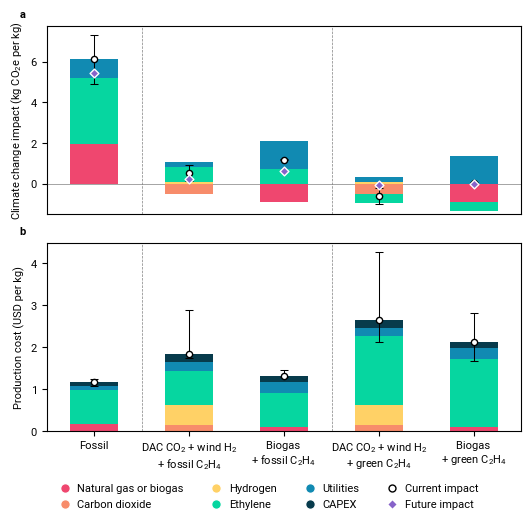

In [38]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (fig_length[1.5], fig_height*0.5))

colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$e per kg)')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax1.scatter(x_pts, climate_change_df['2050 Total'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 2)
ax1.set_title('a', fontproperties = font_prop_bold, x = -0.05)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax1.errorbar(x_pts, climate_change_df['Total'], yerr = 2 * climate_change_df['STDEV'], fmt = 'none', ecolor = '#000000', elinewidth = 0.75, capsize = 3, capthick = 0.75, zorder = 1)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks([])
ylim = ax1.get_ylim()
ax1.set_ylim(-1.5, ylim[1])
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Production cost (USD per kg)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax2.set_title('b', fontproperties = font_prop_bold, x = -0.05)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax2.errorbar(
    x_pts,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax2.yaxis.set_major_locator(MaxNLocator(5))
ax2.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)

labels = ['Natural gas or biogas', 'Carbon dioxide', 'Hydrogen', 'Ethylene', 'Utilities', 'CAPEX', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = 'main_figure'
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

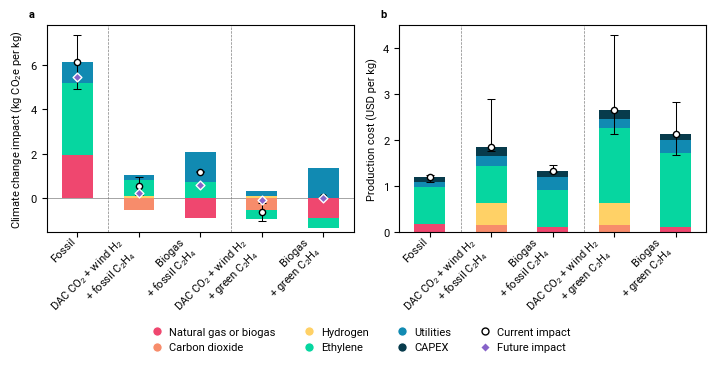

In [39]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.35))

colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$e per kg)')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 45, ha = 'right')  
ax1.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax1.scatter(x_pts, climate_change_df['2050 Total'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 2)
ax1.set_title('a', fontproperties = font_prop_bold, x = -0.05)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax1.errorbar(x_pts, climate_change_df['Total'], yerr = 2 * climate_change_df['STDEV'], fmt = 'none', ecolor = '#000000', elinewidth = 0.75, capsize = 3, capthick = 0.75, zorder = 1)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ylim = ax1.get_ylim()
ax1.set_ylim(-1.5, ylim[1])
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Production cost (USD per kg)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 45, ha = 'right')  
ax2.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax2.set_title('b', fontproperties = font_prop_bold, x = -0.05)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax2.errorbar(
    x_pts,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax2.yaxis.set_major_locator(MaxNLocator(5))
ax2.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)

ax1.xaxis.set_tick_params(rotation = 45, pad = -1)
for tick in ax1.get_xticklabels():
    tick.set_horizontalalignment('right')

ax2.xaxis.set_tick_params(rotation = 45, pad = -1)
for tick in ax2.get_xticklabels():
    tick.set_horizontalalignment('right')

labels = ['Natural gas or biogas', 'Carbon dioxide', 'Hydrogen', 'Ethylene', 'Utilities', 'CAPEX', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.06), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = 'main_figure_horizontal'
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

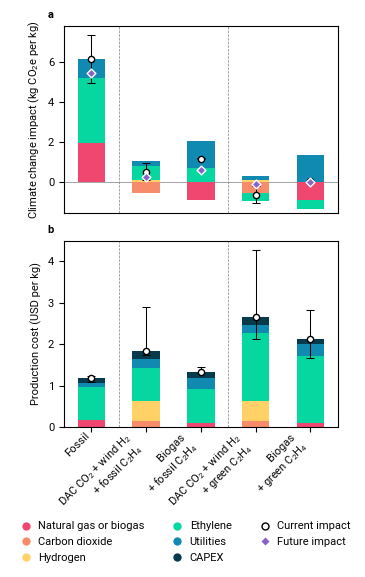

In [40]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (3.34646, fig_height*0.55))

colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$e per kg)')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 45, ha = 'right')  
ax1.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax1.scatter(x_pts, climate_change_df['2050 Total'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 2)
ax1.set_title('a', fontproperties = font_prop_bold, x = -0.05)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax1.errorbar(x_pts, climate_change_df['Total'], yerr = 2 * climate_change_df['STDEV'], fmt = 'none', ecolor = '#000000', elinewidth = 0.75, capsize = 3, capthick = 0.75, zorder = 1)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ylim = ax1.get_ylim()
ax1.set_ylim(-1.5, ylim[1])
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.set_xticks([])

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Production cost (USD per kg)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 45, ha = 'right')  
ax2.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax2.set_title('b', fontproperties = font_prop_bold, x = -0.05)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax2.errorbar(
    x_pts,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
ax2.yaxis.set_major_locator(MaxNLocator(5))
ax2.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)

ax1.xaxis.set_tick_params(rotation = 45, pad = -1)
for tick in ax1.get_xticklabels():
    tick.set_horizontalalignment('right')

ax2.xaxis.set_tick_params(rotation = 45, pad = -1)
for tick in ax2.get_xticklabels():
    tick.set_horizontalalignment('right')

labels = ['Natural gas or biogas', 'Carbon dioxide', 'Hydrogen', 'Ethylene', 'Utilities', 'CAPEX', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.04), ncol = 3, frameon = False, handletextpad = 0.1)

filepath = 'main_figure_vertical'
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)